# Torneo GNN: Predicción de Lipofilicidad Molecular

## Equipo: Viva Chile y Murcia



---
## Sección 1: Setup y Datos

In [1]:
# Instalación de PyTorch Geometric
!pip install torch_geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.7 MB/s eta 0:00:00


In [2]:
import json
import os
import os.path as osp
from zipfile import ZipFile

import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn.functional as F
from torch.nn import (
    Module, Sequential, Linear, BatchNorm1d,
    ReLU, Dropout, ModuleList
)
from torch_geometric.data import InMemoryDataset, download_url
from torch_geometric.loader import DataLoader
from torch_geometric.nn import (
    GCN, MLP,
    GINConv, PNAConv,
    GlobalAttention, GraphNorm,
    global_add_pool, global_mean_pool
)
from torch_geometric.utils import degree
from torch_geometric.utils.convert import from_networkx
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
sns.set_style('darkgrid')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo de cómputo: {DEVICE}')

Dispositivo de cómputo: cuda


In [3]:
class TournamentDataset(InMemoryDataset):

    TOURNAMENT_URL = 'https://drive.upm.es/s/WTBtQ3HH2GjpGAi/download'

    def __init__(self, root, transform=None, pre_transform=None, pre_filter=None):
        super().__init__(root, transform, pre_transform, pre_filter)
        self.data, self.slices = torch.load(self.processed_paths[0], weights_only=False)
        self.train_idx = torch.load(self.processed_paths[1], weights_only=False)
        self.test_idx  = torch.load(self.processed_paths[2], weights_only=False)

    @property
    def raw_file_names(self):
        return ['nx_graphs.zip']

    @property
    def processed_file_names(self):
        return ['geometric_data_processed.pt', 'train_idx.pt', 'test_idx.pt']

    @property
    def num_classes(self):
        return 1

    @property
    def num_features(self):
        return 9

    def download(self):
        download_url(self.TOURNAMENT_URL, self.raw_dir, filename='nx_graphs.zip')

    def process(self):
        with ZipFile(self.raw_paths[0], 'r') as z:
            z.extractall(self.raw_dir)

        data_list, train_idx, test_idx = [], [], []
        for f in sorted(os.listdir(osp.join(self.raw_dir, 'nx_graphs'))):
            G    = nx.read_gml(osp.join(self.raw_dir, 'nx_graphs', f))
            data = from_networkx(G)
            data.x   = data.x.float()
            data.nid = torch.tensor([G.graph['molecule_id']], dtype=torch.long)

            if G.graph['set'] == 'training':
                data.y = torch.tensor([G.graph['y']], dtype=torch.float)
                train_idx.append(G.graph['molecule_id'])
            else:
                data.y = torch.tensor([float('nan')], dtype=torch.float)
                test_idx.append(G.graph['molecule_id'])

            data_list.append(data)

        if self.pre_filter is not None:
            data_list = [d for d in data_list if self.pre_filter(d)]
        if self.pre_transform is not None:
            data_list = [self.pre_transform(d) for d in data_list]

        data_list.sort(key=lambda d: d.nid.item())
        data, slices = self.collate(data_list)
        torch.save((data, slices), self.processed_paths[0])
        torch.save(train_idx,      self.processed_paths[1])
        torch.save(test_idx,       self.processed_paths[2])


dataset = TournamentDataset(root='tournament')
print(f'Total moléculas  : {len(dataset)}')
print(f'Features/nodo    : {dataset.num_features}')
print(f'Grafos training  : {len(dataset.train_idx)}')
print(f'Grafos test      : {len(dataset.test_idx)}')
print(f'Ejemplo de grafo : {dataset[0]}')

Processing...


Total moléculas  : 4200
Features/nodo    : 9
Grafos training  : 3360
Grafos test      : 840
Ejemplo de grafo : Data(x=[22, 9], edge_index=[2, 50], y=[1], molecule_id=[1], set='training', nid=[1])


Done!


count    3360.000000
mean        2.200554
std         1.199276
min        -1.500000
25%         1.437500
50%         2.360000
75%         3.100000
max         4.500000


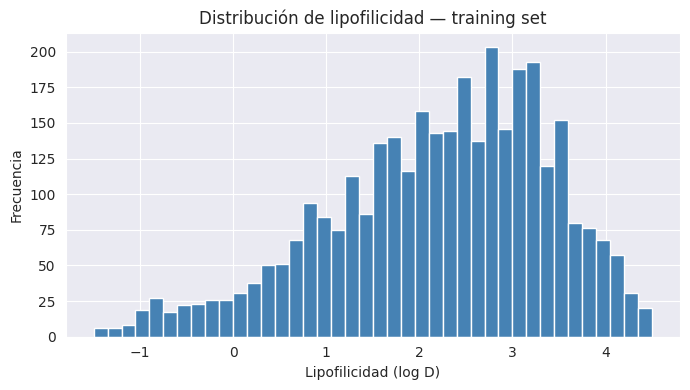

In [4]:
y_series = pd.Series([dataset[i].y.item() for i in dataset.train_idx])
print(y_series.describe().to_string())

fig, ax = plt.subplots(figsize=(7, 4))
y_series.hist(bins=40, ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Distribución de lipofilicidad — training set')
ax.set_xlabel('Lipofilicidad (log D)')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

In [5]:
# Construcción de dataLoaders, split 80/20
train_indices, val_indices = train_test_split(
    dataset.train_idx,
    test_size=0.20,
    random_state=SEED
)

BATCH_SIZE = 64

train_loader = DataLoader(dataset[train_indices], batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(dataset[val_indices],   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(dataset[dataset.test_idx], batch_size=BATCH_SIZE, shuffle=False)

y_train = [dataset[i].y.item() for i in train_indices]
y_val   = [dataset[i].y.item() for i in val_indices]

print(f"Training   : {len(train_indices):>4} grafos | "
      f"μ={pd.Series(y_train).mean():.3f}, σ={pd.Series(y_train).std():.3f}")
print(f"Validación : {len(val_indices):>4} grafos | "
      f"μ={pd.Series(y_val).mean():.3f}, σ={pd.Series(y_val).std():.3f}")
print(f"Test       : {len(dataset.test_idx):>4} grafos (target oculto)")

Training   : 2688 grafos | μ=2.195, σ=1.203
Validación :  672 grafos | μ=2.223, σ=1.184
Test       :  840 grafos (target oculto)


---
## Sección 2: Módulo Compartido de Entrenamiento y Evaluación


In [6]:
def train_model(
    model, optimizer, criterion,
    train_loader, val_loader, device,
    epochs=200, scheduler=None, ckpt_path='best_model.pth'
):
    """
    Parámetros
    ----------
    model        : Module        — red GNN a optimizar
    optimizer    : Optimizer     — instancia de torch.optim
    criterion    : _Loss         — función de pérdida (MSELoss)
    train_loader : DataLoader    — loader de entrenamiento
    val_loader   : DataLoader    — loader de validación
    device       : torch.device
    epochs       : int           — número máximo de épocas
    scheduler    : LRScheduler   — ajuste de tasa de aprendizaje (opcional)
    ckpt_path    : str           — ruta donde se guarda el mejor estado del modelo
    """
    history = {'train_loss': [], 'val_loss': [],
               'train_rmse': [], 'val_rmse': []}
    best_val_rmse = float('inf')

    for epoch in range(1, epochs + 1):
        # Paso de entrenamiento
        model.train()
        total_train_loss = 0.0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            y_pred = model(batch).view(-1)   # [N_grafos_batch]
            y_true = batch.y.view(-1)         # [N_grafos_batch]
            loss   = criterion(y_pred, y_true)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item() * batch.num_graphs

        train_mse  = total_train_loss / len(train_loader.dataset)
        train_rmse = float(np.sqrt(train_mse))

        # Paso de validación
        val_mse, val_rmse = evaluate_model(model, val_loader, device)

        history['train_loss'].append(train_mse)
        history['val_loss'].append(val_mse)
        history['train_rmse'].append(train_rmse)
        history['val_rmse'].append(val_rmse)

        if scheduler is not None:
            scheduler.step(val_mse)

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            torch.save(model.state_dict(), ckpt_path)
            marker = ' ◀ nuevo mínimo'
        else:
            marker = ''

        if epoch % 10 == 0 or epoch == 1:
            lr = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch:03d} | "
                  f"Train RMSE: {train_rmse:.4f} | "
                  f"Val RMSE: {val_rmse:.4f} | "
                  f"LR: {lr:.2e}{marker}")

    history['best_val_rmse'] = best_val_rmse
    print(f"\nEntrenamiento finalizado - Mejor Val RMSE: {best_val_rmse:.4f}")
    return history


@torch.no_grad()
def evaluate_model(model, loader, device):
    """
    Evalúa el modelo sobre un DataLoader en modo inferencia.
    """
    model.eval()
    total_mse = 0.0
    for batch in loader:
        batch  = batch.to(device)
        y_pred = model(batch).view(-1)   # [N_grafos_batch]
        y_true = batch.y.view(-1)         # [N_grafos_batch]
        total_mse += F.mse_loss(y_pred, y_true, reduction='sum').item()

    mse  = total_mse / len(loader.dataset)
    rmse = float(np.sqrt(mse))
    return mse, rmse


def plot_learning_curves(train_losses, val_losses, train_rmse, val_rmse, title=''):
    """
    Genera la gráfica de curvas de aprendizaje (Loss y RMSE) para
    entrenamiento y validación.
    """
    epochs = range(1, len(train_losses) + 1)
    best_rmse = min(val_rmse)
    best_ep   = val_rmse.index(best_rmse) + 1

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f'Curvas de aprendizaje - {title}', fontsize=13)

    # Panel izquierdo: MSE Loss
    axes[0].plot(epochs, train_losses, label='Train MSE', linewidth=1.5)
    axes[0].plot(epochs, val_losses,   label='Val MSE',   linewidth=1.5)
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('MSE')
    axes[0].set_title('MSE Loss')
    axes[0].legend()

    # Panel derecho: RMSE
    axes[1].plot(epochs, train_rmse, label='Train RMSE', linewidth=1.5)
    axes[1].plot(epochs, val_rmse,   label='Val RMSE',   linewidth=1.5)
    axes[1].axvline(best_ep,   linestyle=':', color='gray', linewidth=1)
    axes[1].axhline(best_rmse, linestyle='--', color='red', linewidth=1,
                    label=f'Best Val RMSE = {best_rmse:.4f} (ep. {best_ep})')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('RMSE')
    axes[1].set_title('RMSE')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


@torch.no_grad()
def evaluate_on_test(model, test_loader, test_labels_path, device):
    """
    Calcula el RMSE del modelo sobre el conjunto de test.
    """
    # Carga de etiquetas reales desde CSV
    df_labels = pd.read_csv(test_labels_path)
    label_map  = dict(zip(df_labels['id'].astype(int).tolist(),
                          df_labels['label'].astype(float).tolist()))

    model.eval()
    preds, targets = [], []

    for batch in test_loader:
        batch  = batch.to(device)
        y_pred = model(batch).view(-1)   # [N_grafos_batch]
        nids   = batch.nid.view(-1).cpu().tolist()

        for nid, pred in zip(nids, y_pred.cpu().tolist()):
            if int(nid) in label_map:
                preds.append(pred)
                targets.append(label_map[int(nid)])

    preds   = np.array(preds)
    targets = np.array(targets)
    rmse    = float(np.sqrt(np.mean((preds - targets) ** 2)))

    print(f'Test RMSE ({len(preds)} moléculas): {rmse:.4f}')
    return rmse


def train_epoch(model, loader, optimizer, criterion, device):
    """
    Ejecuta una única época de entrenamiento.
    Retorna RMSE promedio sobre el conjunto de entrenamiento.
    """
    model.train()
    total_mse = 0.0

    for data in loader:
        data   = data.to(device)
        optimizer.zero_grad()

        out    = model(data).view(-1)   # [N_grafos_batch]
        target = data.y.view(-1)        # [N_grafos_batch]

        loss = criterion(out, target)
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            total_mse += F.mse_loss(out, target, reduction='sum').item()

    return float(np.sqrt(total_mse / len(loader.dataset)))


def eval_on_test_labels(model, dataset, device, test_labels_path='test_labels.csv'):
    """
    Evalúa el modelo contra test_labels.csv y muestra RMSE, MAE y gráficos
    de diagnóstico. Diseñada para ejecutarse tras cada bloque de entrenamiento.
    """
    # Generación de predicciones
    model.eval()
    nids, preds = [], []
    loader = DataLoader(dataset[dataset.test_idx], batch_size=128, shuffle=False)

    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out  = model(data).view(-1)
            for nid, pred in zip(data.nid.cpu().tolist(), out.cpu().tolist()):
                nids.append(int(nid))
                preds.append(float(pred))

    if os.path.exists(test_labels_path):
        df_labels = pd.read_csv(test_labels_path)

        required_cols = {'id', 'label'}
        if not required_cols.issubset(df_labels.columns):
            raise ValueError(
                f"test_labels.csv debe contener {required_cols}. "
                f"Columnas encontradas: {set(df_labels.columns)}"
            )

        label_map = dict(zip(df_labels['id'].astype(int).tolist(),
                            df_labels['label'].astype(float).tolist()))

        matched_nids  = [nid for nid in nids if nid in label_map]
        matched_preds = [preds[i] for i, nid in enumerate(nids) if nid in label_map]
        y_true        = [label_map[nid] for nid in matched_nids]

        if len(matched_nids) < len(nids):
            print(f"  AVISO: {len(nids) - len(matched_nids)} moléculas sin etiqueta en el CSV.")

        y_true_np = np.array(y_true,         dtype=np.float32)
        y_pred_np = np.array(matched_preds,  dtype=np.float32)
        residuals = y_pred_np - y_true_np

        rmse = float(np.sqrt(mean_squared_error(y_true_np, y_pred_np)))
        mae  = float(mean_absolute_error(y_true_np, y_pred_np))

        print(f"  Moléculas evaluadas : {len(matched_nids)}")
        print(f"  RMSE sobre test     : {rmse:.4f}")
        print(f"  MAE  sobre test     : {mae:.4f}")

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        # Real vs Predicción
        axes[0].scatter(y_true_np, y_pred_np, alpha=0.45, color='steelblue', s=14)
        lims = [min(y_true_np.min(), y_pred_np.min()) - 0.2,
                max(y_true_np.max(), y_pred_np.max()) + 0.2]
        axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
        axes[0].set_xlim(lims); axes[0].set_ylim(lims)
        axes[0].set_xlabel('Valor real (log D)')
        axes[0].set_ylabel('Predicción (log D)')
        axes[0].set_title('Real vs Predicción - conjunto test')
        axes[0].legend(fontsize=9)

        # Mapa de residuales
        h = axes[1].hist2d(y_true_np, residuals, bins=25, cmap='Blues')
        plt.colorbar(h[3], ax=axes[1], label='Frecuencia')
        axes[1].axhline(0, color='red', linestyle='--', linewidth=1.2)
        axes[1].set_xlabel('Valor real (log D)')
        axes[1].set_ylabel('Residual (Pred − Real)')
        axes[1].set_title('Mapa de residuales - conjunto test')

        plt.tight_layout()
        plt.show()
        return rmse, mae
    else:
        preds_np = np.array(preds, dtype=np.float32)
        print(f"  AVISO : '{test_labels_path}' no encontrado.")
        print(f"  Las etiquetas del test aún no han sido publicadas.")
        print(f"  Predicciones sobre {len(preds_np)} moléculas:")
        print(f"    media={preds_np.mean():.3f} | std={preds_np.std():.3f} | "
              f"min={preds_np.min():.3f} | max={preds_np.max():.3f}")

        fig, ax = plt.subplots(figsize=(7, 3))
        ax.hist(preds_np, bins=40, color='steelblue', edgecolor='white')
        ax.set_xlabel('Lipofilicidad predicha (log D)')
        ax.set_ylabel('Frecuencia')
        ax.set_title('Distribución de predicciones - test sin etiquetas')
        plt.tight_layout()
        plt.show()
        return None, None


print('Módulo de entrenamiento y evaluación cargado correctamente.')

Módulo de entrenamiento y evaluación cargado correctamente.


---
## Sección 3: Modelo Original (GCN Baseline)

### Descripción arquitectónica


| Parámetro | Valor |
|-----------|-------|
| Operador de convolución | GCNConv (normalización simétrica de grado) |
| Capas convolucionales | 3 |
| Dimensión oculta | 64 |
| Dropout | 0.5 |
| Pooling global | `global_add_pool` |
| Cabeza de regresión | MLP 2 capas: 64 → 1 |
| Función de pérdida | HuberLoss |
| Optimizador | Adam (lr=1e-3, wd=5e-4) |

**Limitación principal:** la normalización por grado de GCNConv es fija e
independiente del contexto molecular. La capacidad representacional queda
acotada por la dimensión oculta reducida (64) y la ausencia de scheduler.

In [7]:
from torch_geometric.nn import GCN, MLP, global_add_pool


class GCNGraph(Module):
    """
    GCN Baseline para regresión de grafos moleculares.
    Arquitectura: GCNEncoder → global_add_pool → MLP.
    """
    def __init__(self, num_features: int, num_classes: int,
                 hidden_channels: int = 64, n_layers: int = 3):
        super().__init__()
        torch.manual_seed(SEED)

        self.gcn = GCN(
            in_channels=num_features,       # 9 features atómicas
            hidden_channels=hidden_channels, # dim. oculta = 64
            num_layers=n_layers,             # 3 capas convolucionales
            out_channels=hidden_channels,    # salida del encoder = 64
            dropout=0.5
        )
        self.cls = MLP(
            in_channels=hidden_channels,     # 64
            hidden_channels=hidden_channels, # 64
            out_channels=num_classes,        # 1 (regresión)
            num_layers=2,
            dropout=0.5
        )

    def reset_parameters(self):
        self.gcn.reset_parameters()
        self.cls.reset_parameters()

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.gcn(x.float(), edge_index)
        x = global_add_pool(x, batch)
        x = self.cls(x)

        return x

In [8]:
# Instanciación y configuración del modelo original
model_baseline = GCNGraph(
    num_features=dataset.num_features,  # 9
    num_classes=1
).to(DEVICE)

optimizer_baseline = torch.optim.Adam(
    model_baseline.parameters(), lr=1e-3, weight_decay=5e-4
)
criterion_baseline = torch.nn.HuberLoss()
scheduler_baseline = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_baseline, mode='min', factor=0.5, patience=10, min_lr=1e-6
)

print(f'Parámetros entrenables: {sum(p.numel() for p in model_baseline.parameters()):,}')

Parámetros entrenables: 13,313


In [9]:
# entrenamiento del modelo original
history_baseline = train_model(
    model      = model_baseline,
    optimizer  = optimizer_baseline,
    criterion  = criterion_baseline,
    train_loader = train_loader,
    val_loader   = val_loader,
    device     = DEVICE,
    epochs     = 200,
    scheduler  = scheduler_baseline,
    ckpt_path  = 'best_baseline.pth'
)

Epoch 001 | Train RMSE: 1.2186 | Val RMSE: 1.5589 | LR: 1.00e-03 ◀ nuevo mínimo
Epoch 010 | Train RMSE: 0.8177 | Val RMSE: 1.3756 | LR: 1.00e-03
Epoch 020 | Train RMSE: 0.7824 | Val RMSE: 1.2058 | LR: 5.00e-04
Epoch 030 | Train RMSE: 0.7656 | Val RMSE: 1.2088 | LR: 5.00e-04
Epoch 040 | Train RMSE: 0.7623 | Val RMSE: 1.2636 | LR: 2.50e-04
Epoch 050 | Train RMSE: 0.7631 | Val RMSE: 1.2721 | LR: 1.25e-04
Epoch 060 | Train RMSE: 0.7522 | Val RMSE: 1.2609 | LR: 6.25e-05
Epoch 070 | Train RMSE: 0.7568 | Val RMSE: 1.2687 | LR: 3.13e-05
Epoch 080 | Train RMSE: 0.7516 | Val RMSE: 1.2690 | LR: 1.56e-05
Epoch 090 | Train RMSE: 0.7538 | Val RMSE: 1.2622 | LR: 7.81e-06
Epoch 100 | Train RMSE: 0.7563 | Val RMSE: 1.2701 | LR: 3.91e-06
Epoch 110 | Train RMSE: 0.7600 | Val RMSE: 1.2608 | LR: 1.95e-06
Epoch 120 | Train RMSE: 0.7571 | Val RMSE: 1.2540 | LR: 1.00e-06
Epoch 130 | Train RMSE: 0.7569 | Val RMSE: 1.2551 | LR: 1.00e-06
Epoch 140 | Train RMSE: 0.7581 | Val RMSE: 1.2672 | LR: 1.00e-06
Epoch 150 

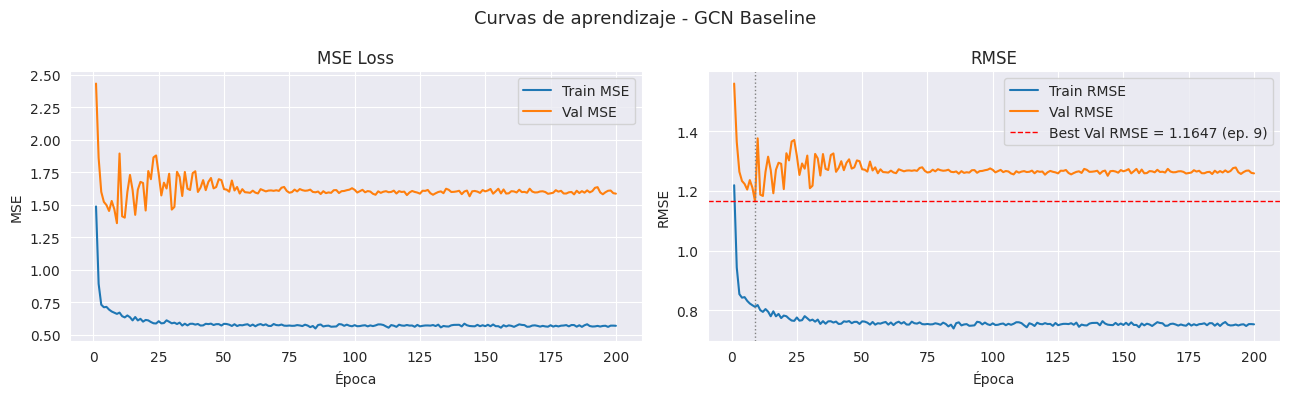

In [10]:
plot_learning_curves(
    history_baseline['train_loss'], history_baseline['val_loss'],
    history_baseline['train_rmse'], history_baseline['val_rmse'],
    title='GCN Baseline'
)

Test RMSE (840 moléculas): 1.2095
  Moléculas evaluadas : 840
  RMSE sobre test     : 1.2095
  MAE  sobre test     : 0.9610


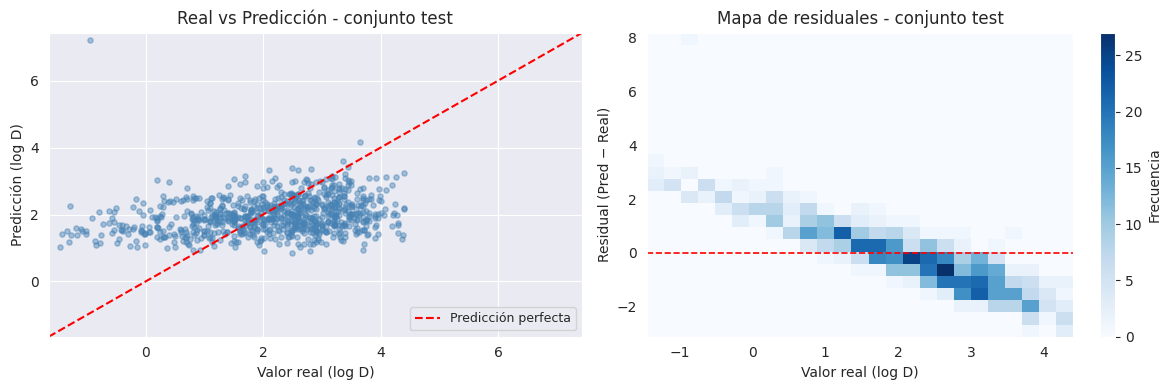

In [12]:
# Carga del mejor checkpoint guardado durante el entrenamiento
model_baseline.load_state_dict(torch.load('best_baseline.pth', map_location=DEVICE))

rmse_baseline_test = evaluate_on_test(
    model            = model_baseline,
    test_loader      = test_loader,
    test_labels_path = 'test_labels.csv',
    device           = DEVICE
)

model_baseline.load_state_dict(torch.load('best_baseline.pth', map_location=DEVICE))
rmse_baseline, mae_baseline = eval_on_test_labels(model_baseline, dataset, DEVICE)

---
## Sección 4: Modelo V1 - GINGraphOptimized

### Cambios arquitectónicos respecto al Baseline


| Parámetro | Baseline | V1 |
|-----------|----------|----|
| Operador | GCNConv | **GINConv** (MLP interno: Linear→BN→ReLU→Linear→ReLU) |
| Capas | 3 | **4** |
| Dimensión oculta | 64 | **128** |
| train_eps | - | **True** |
| Pooling | global_add_pool | **global_add_pool ⊕ global_mean_pool** (concat) |
| Cabeza | MLP 64→1 | **MLP 256→128→64→1** |
| Dropout | 0.5 | 0.5 |

**Pooling dual:** la concatenación de suma y media captura simultáneamente
información de volumen molecular (suma sensible al tamaño del grafo) y de
distribución de propiedades (media invariante al tamaño).

In [13]:
from torch_geometric.nn import GINConv, global_add_pool, global_mean_pool


class GINGraphOptimized(Module):
    """
    GIN Optimizado con pooling dual y MLP interno por capa.
    Arquitectura: Input → 4×GINConv → (Add⊕Mean)Pool → MLP → 1
    """

    def __init__(self, num_features: int, hidden_channels: int = 128,
                 n_layers: int = 4):
        super().__init__()
        torch.manual_seed(SEED)

        self.convs = ModuleList()

        for i in range(n_layers):
            in_dim = num_features if i == 0 else hidden_channels
            # MLP interno de GINConv
            mlp = Sequential(
                Linear(in_dim, hidden_channels),
                BatchNorm1d(hidden_channels),
                ReLU(),
                Linear(hidden_channels, hidden_channels),
                ReLU()
            )
            self.convs.append(GINConv(mlp, train_eps=True))

        # Cabeza de regresión entrada = hidden*2 por concatenación de dos poolings
        self.lin1      = Linear(hidden_channels * 2, hidden_channels)
        self.lin2      = Linear(hidden_channels, hidden_channels // 2)
        self.lin_final = Linear(hidden_channels // 2, 1)
        self.dropout   = Dropout(p=0.5)

    def forward(self, data):
        x, edge_index, batch = data.x.float(), data.edge_index, data.batch
        # x: [N_nodos_batch, 9]

        for conv in self.convs:
            x = conv(x, edge_index)
            x = self.dropout(x)

        x_add  = global_add_pool(x, batch)
        x_mean = global_mean_pool(x, batch)
        x = torch.cat([x_add, x_mean], dim=1)
        x = self.lin1(x).relu()
        x = self.dropout(x)
        x = self.lin2(x).relu()
        x = self.dropout(x)
        out = self.lin_final(x)
        # out: [N_grafos_batch, 1]

        return out.view(-1)

In [14]:
# Instanciación y configuración del modelo v1
model_v1 = GINGraphOptimized(
    num_features=dataset.num_features,  # 9
    hidden_channels=128,
    n_layers=4
).to(DEVICE)

optimizer_v1 = torch.optim.Adam(
    model_v1.parameters(), lr=1e-3, weight_decay=1e-3
)
criterion_v1 = torch.nn.MSELoss()
scheduler_v1 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_v1, mode='min', factor=0.5, patience=10, min_lr=1e-6
)

print(f'Parámetros entrenables: {sum(p.numel() for p in model_v1.parameters()):,}')

Parámetros entrenables: 159,109


In [15]:
# entrenamiento del modelo v1
history_v1 = train_model(
    model        = model_v1,
    optimizer    = optimizer_v1,
    criterion    = criterion_v1,
    train_loader = train_loader,
    val_loader   = val_loader,
    device       = DEVICE,
    epochs       = 200,
    scheduler    = scheduler_v1,
    ckpt_path    = 'best_v1.pth'
)

Epoch 001 | Train RMSE: 1.6613 | Val RMSE: 1.2074 | LR: 1.00e-03 ◀ nuevo mínimo
Epoch 010 | Train RMSE: 1.2084 | Val RMSE: 1.1446 | LR: 1.00e-03
Epoch 020 | Train RMSE: 1.0886 | Val RMSE: 0.9588 | LR: 1.00e-03 ◀ nuevo mínimo
Epoch 030 | Train RMSE: 1.0385 | Val RMSE: 0.9468 | LR: 1.00e-03
Epoch 040 | Train RMSE: 0.9739 | Val RMSE: 0.9557 | LR: 1.00e-03
Epoch 050 | Train RMSE: 0.9541 | Val RMSE: 0.9031 | LR: 1.00e-03
Epoch 060 | Train RMSE: 0.9021 | Val RMSE: 0.8135 | LR: 5.00e-04
Epoch 070 | Train RMSE: 0.8855 | Val RMSE: 0.7853 | LR: 2.50e-04
Epoch 080 | Train RMSE: 0.8487 | Val RMSE: 0.7623 | LR: 2.50e-04
Epoch 090 | Train RMSE: 0.8264 | Val RMSE: 0.8088 | LR: 2.50e-04
Epoch 100 | Train RMSE: 0.8049 | Val RMSE: 0.7620 | LR: 2.50e-04
Epoch 110 | Train RMSE: 0.7739 | Val RMSE: 0.7292 | LR: 1.25e-04
Epoch 120 | Train RMSE: 0.7629 | Val RMSE: 0.7130 | LR: 1.25e-04
Epoch 130 | Train RMSE: 0.7725 | Val RMSE: 0.7191 | LR: 1.25e-04
Epoch 140 | Train RMSE: 0.7614 | Val RMSE: 0.7136 | LR: 6.25

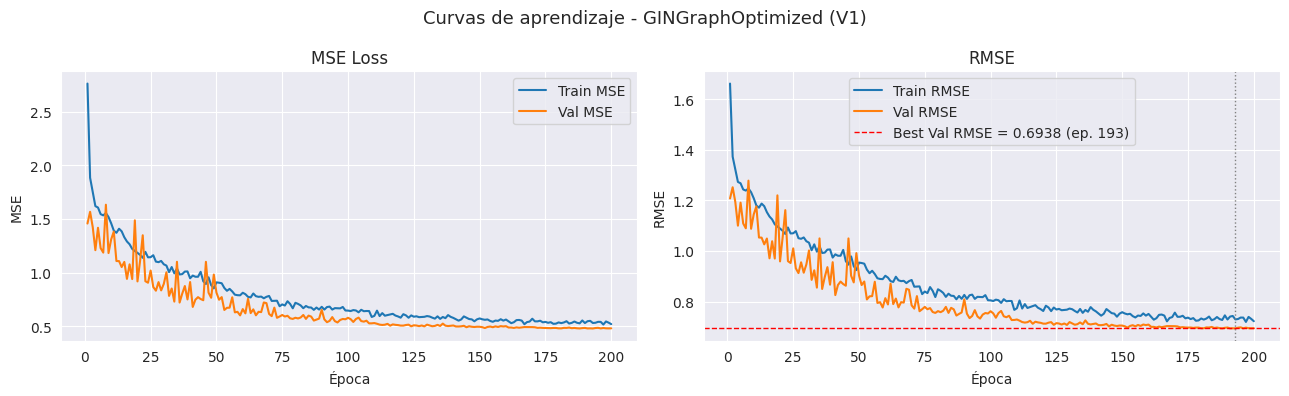

In [16]:
plot_learning_curves(
    history_v1['train_loss'], history_v1['val_loss'],
    history_v1['train_rmse'], history_v1['val_rmse'],
    title='GINGraphOptimized (V1)'
)

Test RMSE (840 moléculas): 0.7615
  Moléculas evaluadas : 840
  RMSE sobre test     : 0.7615
  MAE  sobre test     : 0.5660


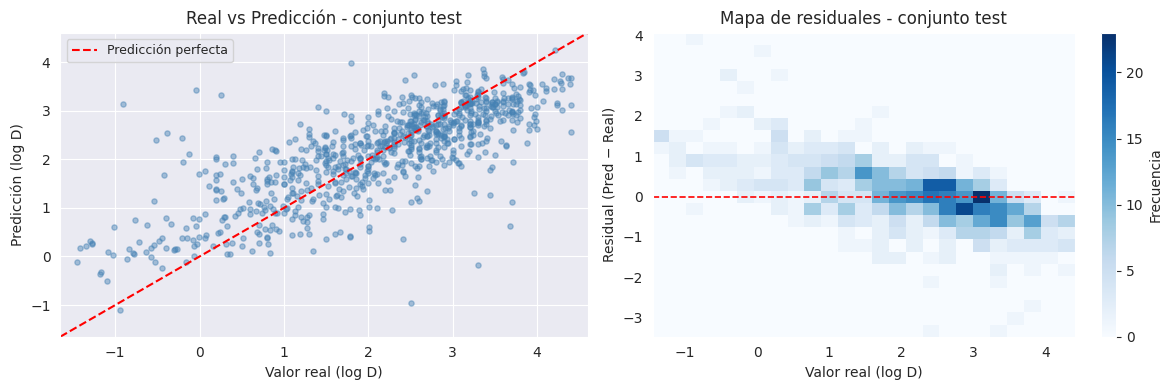

In [17]:
# Evaluación sobre test
model_v1.load_state_dict(torch.load('best_v1.pth', map_location=DEVICE))

rmse_v1_test = evaluate_on_test(
    model            = model_v1,
    test_loader      = test_loader,
    test_labels_path = 'test_labels.csv',
    device           = DEVICE
)

model_v1.load_state_dict(torch.load('best_v1.pth', map_location=DEVICE))
rmse_v1, mae_v1 = eval_on_test_labels(model_v1, dataset, DEVICE)

---
## Sección 5: Modelo V2 - PNA Hybrid Regressor (arquitectura final)

### Descripción técnica

El Modelo V2 adopta **Principal Neighbourhood Aggregation** (Corso et al.,
2020) como operador de convolución. PNA supera las limitaciones de los
agregadores únicos mediante la combinación simultánea de múltiples funciones
de agregación escaladas por el grado del nodo.

| Aspecto | V1 | **V2** |
|---------|-----|--------|
| Operador | GINConv | **PNAConv** |
| Agregadores | Σ (suma) | **mean, min, max, std** |
| Escaladores | - | **identity, amplification, attenuation** |
| Normalización | BatchNorm1d | **GraphNorm** (por grafo) |
| Conexiones residuales | X |  `x = x + h` |
| Proyección de entrada | - | Linear(9 → 80) + ReLU |
| Pooling | Add ⊕ Mean | **GlobalAttention** (atención por nodo) |
| Capas | 4 | 5 |
| Dimensión oculta | 128 | 80 |
| Dropout | 0.5 | 0.4 |

**GraphNorm** normaliza estadísticas por grafo individual en lugar de
por batch, apropiado para datasets con alta variabilidad de tamaño de grafo.

**GlobalAttention** aprende un escalar de importancia por nodo mediante
una red puerta (*gate NN*), ponderando la contribución de cada átomo
a la representación molecular final.

In [18]:
# Pre-cómputo del histograma de grados (requerido por PNAConv)
# PNAConv utiliza la distribución empírica de grados del training set para calibrar los escaladores 'amplification' y 'attenuation'
print('Calculando distribución de grados en training set...')

max_degree = -1
for data in dataset[train_indices]:
    d = degree(data.edge_index[1], num_nodes=data.num_nodes, dtype=torch.long)
    max_degree = max(max_degree, int(d.max()))

deg = torch.zeros(max_degree + 1, dtype=torch.long)
for data in dataset[train_indices]:
    d    = degree(data.edge_index[1], num_nodes=data.num_nodes, dtype=torch.long)
    deg += torch.bincount(d, minlength=deg.numel())

print(f'Grado máximo observado: {max_degree}')
print(f'Tensor deg construido con {deg.numel()} entradas.')

Calculando distribución de grados en training set...
Grado máximo observado: 4
Tensor deg construido con 5 entradas.


In [19]:
class PNAGraphRegressor(Module):
    """
    PNA Hybrid Regressor con conexiones residuales y pooling por atención.
    Arquitectura: Proyección → 5×(PNAConv + GraphNorm + Residual) → GlobalAttention → MLP → 1
    """
    def __init__(self, num_features: int, hidden_channels: int = 80,
                 n_layers: int = 5, dropout: float = 0.4, deg=None):
        super().__init__()
        torch.manual_seed(SEED)

        self.dropout_rate = dropout

        aggregators = ['mean', 'min', 'max', 'std']
        scalers     = ['identity', 'amplification', 'attenuation']

        # Proyección de entrada: alinea la dimensión de entrada con hidden_channels
        self.input_net = Sequential(
            Linear(num_features, hidden_channels),
            ReLU()
        )

        self.convs = ModuleList()
        self.bns   = ModuleList()

        for _ in range(n_layers):
            conv = PNAConv(
                in_channels=hidden_channels,
                out_channels=hidden_channels,
                aggregators=aggregators,
                scalers=scalers,
                deg=deg,               # distribución de grados del training set
                edge_dim=None,
                towers=1,
                pre_layers=1,
                post_layers=1,
                divide_input=False
            )
            self.convs.append(conv)
            self.bns.append(GraphNorm(hidden_channels))

        # gate_nn aprende un escalar de relevancia por nodo
        gate_nn  = Sequential(Linear(hidden_channels, 1), Linear(1, 1))
        self.pool = GlobalAttention(gate_nn, nn=None)

        # Cabeza de regresión
        self.lin1 = Linear(hidden_channels, hidden_channels // 2)
        self.lin2 = Linear(hidden_channels // 2, 1)

    def forward(self, data):
        x, edge_index, batch = data.x.float(), data.edge_index, data.batch

        x = self.input_net(x)

        for conv, bn in zip(self.convs, self.bns):
            h = conv(x, edge_index)
            h = bn(h)
            h = F.relu(h)
            h = F.dropout(h, p=self.dropout_rate, training=self.training)
            x = x + h

        x = self.pool(x, batch)
        x = F.relu(self.lin1(x))
        x = F.dropout(x, p=self.dropout_rate, training=self.training)
        out = self.lin2(x)


        return out.view(-1)

In [20]:
# Instanciación y configuración del modelo v2
model_v2 = PNAGraphRegressor(
    num_features=dataset.num_features,
    hidden_channels=80,
    n_layers=5,
    dropout=0.4,
    deg=deg
).to(DEVICE)

optimizer_v2 = torch.optim.Adam(
    model_v2.parameters(), lr=1e-3, weight_decay=1e-4
)
criterion_v2 = torch.nn.MSELoss()
scheduler_v2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_v2, mode='min', factor=0.5, patience=15, min_lr=1e-6
)

print(f'Parámetros entrenables: {sum(p.numel() for p in model_v2.parameters()):,}')

Parámetros entrenables: 518,564


/tmp/ipykernel_1203/1671523257.py:43: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool = GlobalAttention(gate_nn, nn=None)


In [21]:
# Entrenamiento del modelo v2
history_v2 = train_model(
    model        = model_v2,
    optimizer    = optimizer_v2,
    criterion    = criterion_v2,
    train_loader = train_loader,
    val_loader   = val_loader,
    device       = DEVICE,
    epochs       = 200,
    scheduler    = scheduler_v2,
    ckpt_path    = 'best_v2_pna.pth'
)

/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='min')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch 001 | Train RMSE: 1.4025 | Val RMSE: 1.1689 | LR: 1.00e-03 ◀ nuevo mínimo
Epoch 010 | Train RMSE: 1.0830 | Val RMSE: 0.9096 | LR: 1.00e-03 ◀ nuevo mínimo
Epoch 020 | Train RMSE: 0.9499 | Val RMSE: 0.8062 | LR: 1.00e-03 ◀ nuevo mínimo
Epoch 030 | Train RMSE: 0.8783 | Val RMSE: 0.7804 | LR: 1.00e-03
Epoch 040 | Train RMSE: 0.8106 | Val RMSE: 0.7224 | LR: 1.00e-03 ◀ nuevo mínimo
Epoch 050 | Train RMSE: 0.7947 | Val RMSE: 0.6984 | LR: 1.00e-03 ◀ nuevo mínimo
Epoch 060 | Train RMSE: 0.7845 | Val RMSE: 0.7110 | LR: 1.00e-03
Epoch 070 | Train RMSE: 0.7338 | Val RMSE: 0.6838 | LR: 1.00e-03
Epoch 080 | Train RMSE: 0.7182 | Val RMSE: 0.7099 | LR: 1.00e-03
Epoch 090 | Train RMSE: 0.6875 | Val RMSE: 0.6793 | LR: 1.00e-03
Epoch 100 | Train RMSE: 0.6964 | Val RMSE: 0.6740 | LR: 1.00e-03
Epoch 110 | Train RMSE: 0.6888 | Val RMSE: 0.6699 | LR: 1.00e-03
Epoch 120 | Train RMSE: 0.6740 | Val RMSE: 0.6472 | LR: 1.00e-03 ◀ nuevo mínimo
Epoch 130 | Train RMSE: 0.6664 | Val RMSE: 0.6535 | LR: 1.00e-03


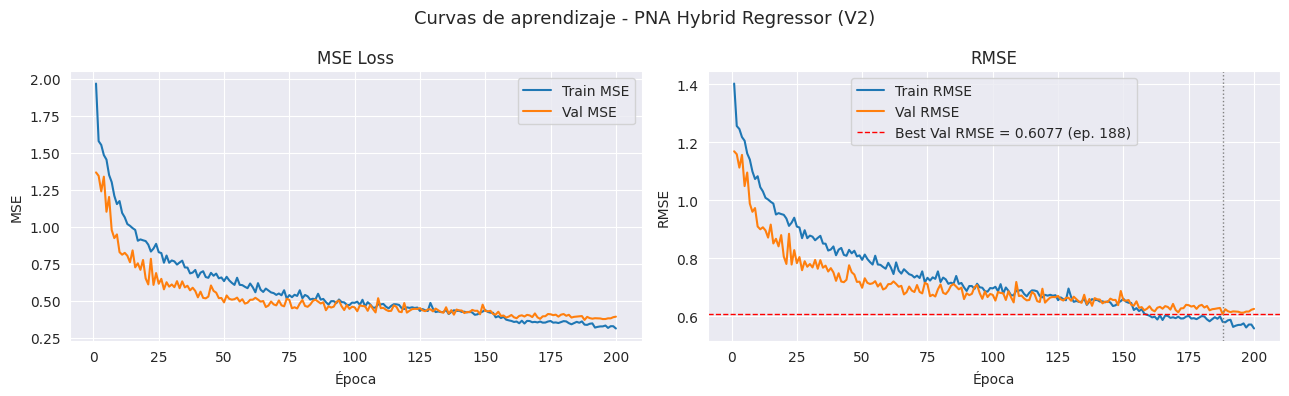

In [22]:
plot_learning_curves(
    history_v2['train_loss'], history_v2['val_loss'],
    history_v2['train_rmse'], history_v2['val_rmse'],
    title='PNA Hybrid Regressor (V2)'
)

Test RMSE (840 moléculas): 0.6898
  Moléculas evaluadas : 840
  RMSE sobre test     : 0.6889
  MAE  sobre test     : 0.4898


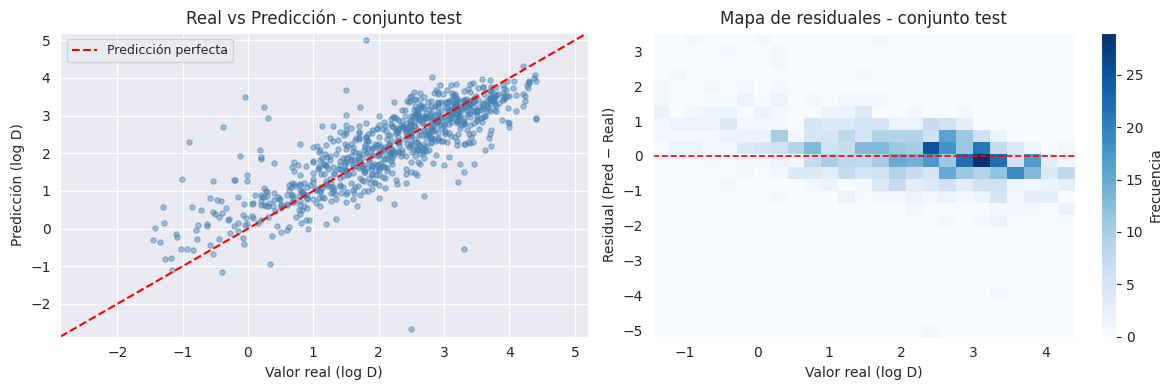

In [23]:
# evaluación sobre test
model_v2.load_state_dict(torch.load('best_v2_pna.pth', map_location=DEVICE))

rmse_v2_test = evaluate_on_test(
    model            = model_v2,
    test_loader      = test_loader,
    test_labels_path = 'test_labels.csv',
    device           = DEVICE
)
model_v2.load_state_dict(torch.load('best_v2_pna.pth', map_location=DEVICE))
rmse_v2, mae_v2 = eval_on_test_labels(model_v2, dataset, DEVICE)

---
## Sección 6: Resumen Comparativo

                Modelo  Val RMSE (mejor)  Test RMSE
PNAGraphRegressor (V2)            0.6077     0.6898
GINGraphOptimized (V1)            0.6938     0.7615
          GCN Baseline            1.1647     1.2095


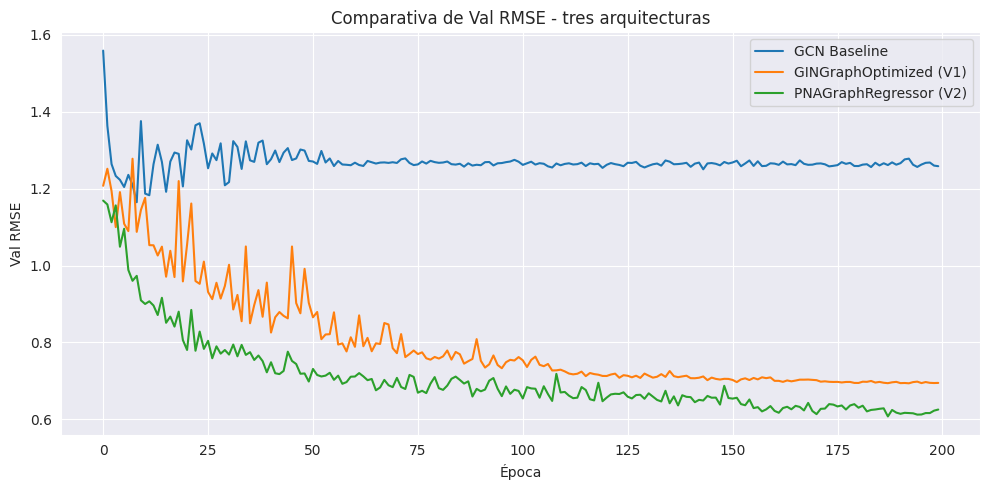

In [24]:
results = {
    'Modelo': ['GCN Baseline', 'GINGraphOptimized (V1)', 'PNAGraphRegressor (V2)'],
    'Val RMSE (mejor)': [
        history_baseline['best_val_rmse'],
        history_v1['best_val_rmse'],
        history_v2['best_val_rmse']
    ],
    'Test RMSE': [rmse_baseline_test, rmse_v1_test, rmse_v2_test]
}

df_results = pd.DataFrame(results)
df_results = df_results.sort_values('Test RMSE').reset_index(drop=True)
df_results[['Val RMSE (mejor)', 'Test RMSE']] = df_results[['Val RMSE (mejor)', 'Test RMSE']].round(4)
print(df_results.to_string(index=False))

# Gráfica comparativa de curvas de validación
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history_baseline['val_rmse'], label='GCN Baseline',             linewidth=1.5)
ax.plot(history_v1['val_rmse'],       label='GINGraphOptimized (V1)',    linewidth=1.5)
ax.plot(history_v2['val_rmse'],       label='PNAGraphRegressor (V2)',    linewidth=1.5)
ax.set_xlabel('Época')
ax.set_ylabel('Val RMSE')
ax.set_title('Comparativa de Val RMSE - tres arquitecturas')
ax.legend()
plt.tight_layout()
plt.show()

## Bloque Final — Serialización de artefactos MLOps

Guarda los tres artefactos necesarios para el despliegue en producción:
- `best_model.pth`: pesos del PNAGraphRegressor (mejor checkpoint Val RMSE)
- `deg.pt`: histograma de grados del training set (requerido por PNAConv)
- `model_config.json`: configuración de arquitectura y métricas finales

In [25]:
import json, os, shutil

os.makedirs("artifacts", exist_ok=True)

# 1 — Pesos del mejor modelo (checkpoint guardado por train_model)
shutil.copy("best_v2_pna.pth", "artifacts/best_model.pth")

# 2 — Tensor deg (CRÍTICO: PNAConv no puede instanciarse sin él)
torch.save(deg, "artifacts/deg.pt")

# 3 — Configuración del modelo y métricas
model_config = {
    "model_class":      "PNAGraphRegressor",
    "checkpoint":       "best_model.pth",
    "num_features":     int(dataset.num_features),   # 9
    "hidden_channels":  80,
    "n_layers":         5,
    "dropout":          0.4,
    "aggregators":      ["mean", "min", "max", "std"],
    "scalers":          ["identity", "amplification", "attenuation"],
    "task":             "regression",
    "target":           "lipophilicity_logD",
    "seed":             SEED,
    "best_val_rmse":    round(history_v2["best_val_rmse"], 4),
    "deg_size":         int(deg.numel()),
}
with open("artifacts/model_config.json", "w") as f:
    json.dump(model_config, f, indent=2)

# Verificación
print("=" * 50)
print("  ARTEFACTOS GUARDADOS")
print("=" * 50)
print(f"  best_model.pth  : {os.path.getsize('artifacts/best_model.pth') / 1e3:.1f} KB")
print(f"  deg.pt          : {os.path.getsize('artifacts/deg.pt') / 1e3:.1f} KB  — {int(deg.numel())} entradas")
print(f"  model_config.json:")
print(json.dumps(model_config, indent=4))

  ARTEFACTOS GUARDADOS
  best_model.pth  : 2099.6 KB
  deg.pt          : 1.5 KB  — 5 entradas
  model_config.json:
{
    "model_class": "PNAGraphRegressor",
    "checkpoint": "best_model.pth",
    "num_features": 9,
    "hidden_channels": 80,
    "n_layers": 5,
    "dropout": 0.4,
    "aggregators": [
        "mean",
        "min",
        "max",
        "std"
    ],
    "scalers": [
        "identity",
        "amplification",
        "attenuation"
    ],
    "task": "regression",
    "target": "lipophilicity_logD",
    "seed": 42,
    "best_val_rmse": 0.6077,
    "deg_size": 5
}


In [26]:
import shutil
shutil.make_archive("artifacts_export", "zip", "artifacts")
print("Listo para descargar: artifacts_export.zip")

Listo para descargar: artifacts_export.zip
